# Linear Models

__TABLE OF CONTENTS__

1. [Introduction](#intro)
2. [Setup and Data Preparation](#setup)
3. [Baseline Model: Linear Regression (All Features)](#lin-full)
4. [Ridge Regression (L2) (All Features)](#ridge-full)
5. [Lasso Regression (L1) (All Features)](#lasso-full)
6. [Elastic Net Regression (L1 + L2) (All Features)](#elastic-full)
7. [Comparative Analysis](#comparison)
8. [Elastic Net Variants](#en-var)
9. [Closing Summary](#summary)

<a id="intro"></a>
## 1. Introduction

This notebook examines the family of linear and regularized regression models that form the foundation of our benchmarking pipeline. These models provide a structured, interpretable framework for understanding how the input features relate to car prices and serve as the starting point from which more flexible models are later evaluated.

The goal of this section is two-fold:
- First, we establish Ordinary Least Squares as a clear and transparent baseline against which all other algorithms must demonstrate improvement.
- Second, we explore three regularized variants (Ridge, Lasso and Elastic Net) that extend the linear model by introducing penalties to address issues such as multicollinearity, coefficient instability and noisy predictors.

Working through these models together allows us to:
1. Build a consistent baseline of performance before introducing non-linear methods;
2. Examine how regularization alters coefficient behavior and model complexity;
3. Detect structural characteristics of the dataset (correlations, sparsity, noise) that may guide later modeling choices;
4. Compare interpretability and predictive accuracy across increasingly flexible linear approaches.

By evaluating these models under a unified preprocessing and cross-validation framework, we create a solid analytical benchmark that informs and justifies the transition to tree-based ensembles, boosting methods, and other non-linear algorithms explored later in the project.

<a id="setup"></a>
## 2. Setup and Data Preparation

### 2.1. Imports and Utilities

In [1]:
from datetime import datetime

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import ParameterSampler
from sklearn.feature_selection import SelectFromModel

### 2.2. Loading Data and Preprocessing / Visualization Functions

In [2]:
# Import pre processing helpers
#    -> this should define: full_train_dataset, cat_feat, num_feat,
#       basic_string_transformer, def_string_basic_transformer,
#       preprocess_categorical, MyTargetEncoder, MyOneHotEncoder, etc.
%run 05_0_preproc_helpers.ipynb

# Import visualization functions for model assessment and comparison
%run 05_0.1_visualization_helpers.ipynb  


# Define target
TARGET_COL = "price"

# Separate X and y from the treated dataset
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# Numerical and categorical features (splitted in pre processing)
numeric_features = num_feat
categorical_features = cat_feat

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


<a id="lin-full"></a>
## 3. Baseline Model: Ordinary Least Squares

### 3.1. Model Introduction

Linear Regression provides the baseline against which all subsequent models are evaluated. It fits a weighted linear combination of the features, offering a transparent view of how each predictor contributes to price estimation. 

Its simplicity and interpretability make it the natural starting point for our regression analysis.

### 3.2. Cross-Validation Results

In [ ]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold configuration
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Containers for overall CV metrics
cv_fold_rmses_train = []
cv_fold_maes_train  = []
cv_fold_r2s_train   = []
cv_fold_bias_train  = []

cv_fold_rmses_val = []
cv_fold_maes_val  = []
cv_fold_r2s_val   = []
cv_fold_bias_val  = []

log_path = "linreg_cv_log.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        """
        Write a message to a log file with timestamp, keeping track of what's happening while keeping the notebook output clean.
        """
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# LINEAR REGRESSION - K-FOLD CV")
    log("# =============================")
    log(f"N_SPLITS = {N_SPLITS}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        log("")
        log(f"==== FOLD {fold}/{N_SPLITS} ====")

        # 1) SEPARATE TRAIN / VALIDATION
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        log(f"[F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
        log(f"[F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

        # NaNs before numeric imputation
        log(f"[F{fold}] NaNs before numeric imputation (num features):")
        log(str(X_train[numeric_features].isna().sum()))

        log(f"[F{fold}] NaNs before (categoricals):")
        log(str(X_train[categorical_features].isna().sum()))

        unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
        log(f"[F{fold}] 'UNKNOWN' before (categoricals):")
        log(str(unknown_counts_before))

        # 2) NUMERICAL PRE PROCESSING (fit on train, transform train/val)
        year_state = fit_year_median(
            X_train,
            year_col="year",
            model_col="model"
        )
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(
            X_train,
            mileage_col="mileage",
            do_abs=True
        )
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(
            X_train,
            engine_col="engineSize"
        )
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        tax_state = fit_tax_imputer(
            X_train,
            tax_col="tax",
            do_abs=True
        )
        X_train = transform_tax_imputer(X_train, state=tax_state)
        X_val   = transform_tax_imputer(X_val,   state=tax_state)

        mpg_state = fit_mpg_imputer(
            X_train,
            mpg_col="mpg",
            do_abs=True
        )
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        owners_state = fit_previous_owners_imputer(
            X_train,
            owners_col="previousOwners",
            year_col="year",
            mileage_col="mileage"
        )
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

        log(f"[F{fold}] After numeric imputation: X_train shape = {X_train.shape}, X_val shape = {X_val.shape}")
        log(f"[F{fold}] NaNs after numeric imputation (num features):")
        log(str(X_train[numeric_features].isna().sum()))

        # 3) CATEGORICAL RESOLVERS (fit on train, transform train/val)
        # Brand
        brand_state = fit_ambiguous_brand_resolver(
            train_df=X_train,
            valid_brands=valid_brands,
            brand_col="Brand",
            model_col="model",
            year_col="year",
        )

        X_train, _, brand_still_invalid_train = transform_ambiguous_brands(
            X_train,
            brand_state,
        )
        X_val, _, brand_still_invalid_val = transform_ambiguous_brands(
            X_val,
            brand_state,
        )

        log(f"[F{fold}] After solving Brand - still invalid (train): {len(brand_still_invalid_train)}")

        # Model
        model_state = fit_invalid_model_resolver(
            train_df=X_train,
            valid_models_by_brand=valid_models_by_brand,
            brand_col="Brand",
            model_col="model",
            year_col="year",
            fuel_col="fuelType",
            mpg_col="mpg",
        )

        X_train, _, model_still_invalid_train = transform_invalid_models(
            X_train,
            model_state,
        )
        X_val, _, model_still_invalid_val = transform_invalid_models(
            X_val,
            model_state,
        )

        log(f"[F{fold}] After solving model - still invalid (train): {len(model_still_invalid_train)}")

        # Transmission
        transm_state = fit_transmission_resolver(
            train_df=X_train,
            valid_transmissions=valid_transmissions,
            transm_col="transmission",
            brand_col="Brand",
            model_col="model",
            fuel_col="fuelType",
        )

        X_train, _, transm_still_invalid_train = transform_transmission_resolver(
            X_train,
            transm_state,
        )
        X_val, _, transm_still_invalid_val = transform_transmission_resolver(
            X_val,
            transm_state,
        )

        log(f"[F{fold}] After solving transmission - distinct (train): "
            + str(sorted(X_train["transmission"].astype(str).str.upper().unique())))

        # Fuel Type
        fuel_state = fit_fueltype_resolver(
            train_df=X_train,
            valid_fueltypes=valid_fueltypes,
            fuel_col="fuelType",
            brand_col="Brand",
            model_col="model",
            transm_col="transmission",
        )

        X_train, _, fuel_still_invalid_train = transform_fueltype_resolver(
            X_train,
            fuel_state,
        )
        X_val, _, fuel_still_invalid_val = transform_fueltype_resolver(
            X_val,
            fuel_state,
        )

        log(f"[F{fold}] After solving fuelType - distinct (train): "
            + str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))

        # 4) SUMMARY STATS 
        log(f"[F{fold}] --- NUMERICAL (train, after imputation) ---")
        log(str(X_train[numeric_features].describe().T[["mean", "std", "min", "max"]]))
        log("NaNs (train):")
        log(str(X_train[numeric_features].isna().sum()))

        log(f"[F{fold}] --- CATEGORICAL (train, after resolvers) ---")
        log("NaNs (train):")
        log(str(X_train[categorical_features].isna().sum()))
        log("'UNKNOWN' counts (train):")
        log(str((X_train[categorical_features] == "UNKNOWN").sum()))

        # 5) CATEGORICAL ENCODING
        high_card_features = ["Brand", "model"]  # target encoding
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        log(f"[F{fold}] high_card_features = {high_card_features}")
        log(f"[F{fold}] low_card_features  = {low_card_features}")

        # Target Encoding for high-card features
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train)

        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        # One-Hot Encoding for low-card features
        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])

        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

        log(f"[F{fold}] X_train_cat shape: {X_train_cat.shape}")
        log(f"[F{fold}] X_val_cat   shape: {X_val_cat.shape}")

        # 6) NUMERIC SCALING
        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(X_train[numeric_features])
        X_val_num   = scaler.transform(X_val[numeric_features])

        X_train_num_df = pd.DataFrame(
            X_train_num,
            index=X_train.index,
            columns=[f"num_{col}" for col in numeric_features]
        )
        X_val_num_df = pd.DataFrame(
            X_val_num,
            index=X_val.index,
            columns=[f"num_{col}" for col in numeric_features]
        )

        log(f"[F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
        log(f"[F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

        # 7) FINAL MATRIX (num + cat)
        X_train_final = pd.concat(
            [X_train_num_df, X_train_cat],
            axis=1
        )
        X_val_final = pd.concat(
            [X_val_num_df, X_val_cat],
            axis=1
        )

        log(f"[F{fold}] X_train_final shape: {X_train_final.shape}")
        log(f"[F{fold}] X_val_final   shape: {X_val_final.shape}")

        # 8) LINEAR REGRESSION MODEL
        linreg = LinearRegression(fit_intercept=True)

        log(f"[F{fold}] Training LinearRegression...")
        linreg.fit(X_train_final, y_train)

        # Predictions
        y_pred_train = linreg.predict(X_train_final)
        y_pred_val   = linreg.predict(X_val_final)

        # 9) METRICS
        # Validation
        mse_val  = mean_squared_error(y_val, y_pred_val)
        rmse_val = np.sqrt(mse_val)
        mae_val  = mean_absolute_error(y_val, y_pred_val)
        r2_val   = r2_score(y_val, y_pred_val)
        bias_val = float(np.mean(y_pred_val - y_val))  # signed bias (pred - true)
        # If bias > 0: on average we are overpredicting; bias < 0: underpredicting

        # Train
        mse_tr  = mean_squared_error(y_train, y_pred_train)
        rmse_tr = np.sqrt(mse_tr)
        mae_tr  = mean_absolute_error(y_train, y_pred_train)
        r2_tr   = r2_score(y_train, y_pred_train)
        bias_tr = float(np.mean(y_pred_train - y_train))

        log(f"[F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
        log(f"[F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

        # Store for global CV averages
        cv_fold_rmses_train.append(rmse_tr)
        cv_fold_maes_train.append(mae_tr)
        cv_fold_r2s_train.append(r2_tr)
        cv_fold_bias_train.append(bias_tr)

        cv_fold_rmses_val.append(rmse_val)
        cv_fold_maes_val.append(mae_val)
        cv_fold_r2s_val.append(r2_val)
        cv_fold_bias_val.append(bias_val)

    # CV SUMMARY
    log("")
    log("# ========== CV SUMMARY (LINEAR REGRESSION) ==========")
    log(f"TRAIN -> RMSE mean: {np.mean(cv_fold_rmses_train):.2f} | MAE mean: {np.mean(cv_fold_maes_train):.2f} | R2 mean: {np.mean(cv_fold_r2s_train):.4f} | Bias mean: {np.mean(cv_fold_bias_train):.2f}")
    log(f"VAL   -> RMSE mean: {np.mean(cv_fold_rmses_val):.2f} | MAE mean: {np.mean(cv_fold_maes_val):.2f} | R2 mean: {np.mean(cv_fold_r2s_val):.4f} | Bias mean: {np.mean(cv_fold_bias_val):.2f}")

print(f"Linear Regression CV finished. Detailed logs in: {log_path}")

Linear Regression CV finished. Detailed logs in: linreg_cv_log.txt


<a id="ridge-full"></a>
## 4. Ridge Regression (L2 Regularization)

### 4.1. Model Introduction

Ridge Regression extends the baseline model by applying an L2 penalty to shrink coefficients toward zero.

This stabilizes the solution when predictors are correlated and reduces overfitting by preventing large, unstable weights. Ridge maintains all features in the model, but moderates their influence, providing a more robust estimate when the data exhibits multicollinearity or high variance.

It allows us to assess whether controlled shrinkage improves generalization without compromising interpretability.

### 4.2. Hyperparameter Search (K-Fold)

In [12]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold config
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Hyperparameter space for Ridge
ridge_param_distributions = {
    #"alpha": np.logspace(-3, 3, 40)  # 1e-3 to 1e3
    "alpha": np.logspace(-5, 1, 200)  # testing lower alphas since standard linear regression performed better than ridge with higher alphas
}

N_RANDOM_CONFIGS_RIDGE = 40

ridge_sampler = ParameterSampler(
    ridge_param_distributions,
    n_iter=N_RANDOM_CONFIGS_RIDGE,
    random_state=RANDOM_STATE
)

ridge_search_results = []

# Best configs
ridge_best_rmse = np.inf
ridge_best_config_rmse = None

ridge_best_mae = np.inf
ridge_best_config_mae = None

ridge_best_combo = np.inf
ridge_best_config_combo = None

ridge_log_path = "ridge_random_search_log.txt"

with open(ridge_log_path, "w", encoding="utf-8") as log_file:

    def log_ridge(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_ridge("# =============================")
    log_ridge("# START OF RANDOM SEARCH Ridge")
    log_ridge("# =============================")
    log_ridge(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_RIDGE}")
    log_ridge(f"param_distributions = {ridge_param_distributions}")

    for config_id, params in enumerate(ridge_sampler, start=1):
        log_ridge("")
        log_ridge(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_RIDGE} ########")
        log_ridge(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            log_ridge("")
            log_ridge(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            # 1) split
            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            log_ridge(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log_ridge(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # NaNs before numeric imputation
            log_ridge(f"[C{config_id}|F{fold}] NaNs before numeric imputation (num features):")
            log_ridge(str(X_train[numeric_features].isna().sum()))

            log_ridge(f"[C{config_id}|F{fold}] NaNs before (categoricals):")
            log_ridge(str(X_train[categorical_features].isna().sum()))

            unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
            log_ridge(f"[C{config_id}|F{fold}] 'UNKNOWN' before (categoricals):")
            log_ridge(str(unknown_counts_before))

            # 2) NUMERIC PREPROCESSING
            year_state = fit_year_median(
                X_train,
                year_col="year",
                model_col="model"
            )
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(
                X_train,
                mileage_col="mileage",
                do_abs=True
            )
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(
                X_train,
                engine_col="engineSize"
            )
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(
                X_train,
                tax_col="tax",
                do_abs=True
            )
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(
                X_train,
                mpg_col="mpg",
                do_abs=True
            )
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(
                X_train,
                owners_col="previousOwners",
                year_col="year",
                mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            log_ridge(f"[C{config_id}|F{fold}] After numeric imputation: X_train shape = {X_train.shape}, X_val shape = {X_val.shape}")
            log_ridge(f"[C{config_id}|F{fold}] NaNs after numeric imputation (num features):")
            log_ridge(str(X_train[numeric_features].isna().sum()))

            # 3) CATEGORICAL RESOLVERS
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )
            X_train, _, brand_still_invalid_train = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, brand_still_invalid_val   = transform_ambiguous_brands(X_val,   brand_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving Brand - still invalid (train): {len(brand_still_invalid_train)}")

            model_state = fit_invalid_model_resolver(
                train_df=X_train,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )
            X_train, _, model_still_invalid_train = transform_invalid_models(X_train, model_state)
            X_val,   _, model_still_invalid_val   = transform_invalid_models(X_val,   model_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving model - still invalid (train): {len(model_still_invalid_train)}")

            transm_state = fit_transmission_resolver(
                train_df=X_train,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
            )
            X_train, _, transm_still_invalid_train = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, transm_still_invalid_val   = transform_transmission_resolver(X_val,   transm_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving transmission - distinct (train): " +
                      str(sorted(X_train["transmission"].astype(str).str.upper().unique())))

            fuel_state = fit_fueltype_resolver(
                train_df=X_train,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
            )
            X_train, _, fuel_still_invalid_train = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, fuel_still_invalid_val   = transform_fueltype_resolver(X_val,   fuel_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving fuelType - distinct (train): " +
                      str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))

            # 4) CATEGORICAL ENCODING
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            log_ridge(f"[C{config_id}|F{fold}] high_card_features = {high_card_features}")
            log_ridge(f"[C{config_id}|F{fold}] low_card_features  = {low_card_features}")

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            log_ridge(f"[C{config_id}|F{fold}] X_train_cat shape: {X_train_cat.shape}")
            log_ridge(f"[C{config_id}|F{fold}] X_val_cat   shape: {X_val_cat.shape}")

            # 5) NUMERIC SCALING
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            log_ridge(f"[C{config_id}|F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
            log_ridge(f"[C{config_id}|F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

            # 6) FINAL MATRIX
            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            log_ridge(f"[C{config_id}|F{fold}] X_train_final shape: {X_train_final.shape}")
            log_ridge(f"[C{config_id}|F{fold}] X_val_final   shape: {X_val_final.shape}")

            # 7) RIDGE MODEL
            ridge = Ridge(
                alpha=params["alpha"],
                fit_intercept=True
            )

            log_ridge(f"[C{config_id}|F{fold}] Training Ridge...")
            ridge.fit(X_train_final, y_train)

            y_pred_train = ridge.predict(X_train_final)
            y_pred_val   = ridge.predict(X_val_final)

            # 8) METRICS
            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log_ridge(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_ridge(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        # mean over folds
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_ridge("")
        log_ridge(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_ridge(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_ridge(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        ridge_search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "bias_mean": mean_bias_val,
            "combo_score": combo_score,
        })

        # best by RMSE
        if mean_rmse_val < ridge_best_rmse:
            ridge_best_rmse = mean_rmse_val
            ridge_best_config_rmse = {**params}
            log_ridge(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {ridge_best_rmse:.2f}")

        # best by MAE
        if mean_mae_val < ridge_best_mae:
            ridge_best_mae = mean_mae_val
            ridge_best_config_mae = {**params}
            log_ridge(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {ridge_best_mae:.2f}")

        # best by combo
        if combo_score < ridge_best_combo:
            ridge_best_combo = combo_score
            ridge_best_config_combo = {**params}
            log_ridge(f"[NEW BEST COMBINED] Config {config_id} with score = {ridge_best_combo:.2f}")

    log_ridge("")
    log_ridge("# =============================")
    log_ridge("# END OF RANDOM SEARCH Ridge")
    log_ridge("# =============================")
    log_ridge(f"Best configuration (min RMSE VAL): {ridge_best_config_rmse}")
    log_ridge(f"Best average RMSE (VAL): {ridge_best_rmse:.2f}")
    log_ridge(f"Best configuration (min MAE VAL): {ridge_best_config_mae}")
    log_ridge(f"Best average MAE  (VAL): {ridge_best_mae:.2f}")
    log_ridge(f"Best configuration (combined score VAL): {ridge_best_config_combo}")
    log_ridge(f"Best combined score (VAL): {ridge_best_combo:.2f}")

ridge_results_df = pd.DataFrame(ridge_search_results)
ridge_results_df_sorted = ridge_results_df.sort_values(by="mae_mean", ascending=True)

display(ridge_results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(ridge_best_config_rmse)
print("Best average RMSE (VAL):", ridge_best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(ridge_best_config_mae)
print("Best average MAE (VAL):", ridge_best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(ridge_best_config_combo)
print("Best combined score (VAL):", ridge_best_combo)

ridge_results_df_sorted.to_csv("ridge_random_search_results.csv", index=False)
print(f"\nDetailed logs in: {ridge_log_path}")

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.08495e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.11017e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.12825e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.18995e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/e

,config_id,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
14,15,4.055461,4157.772338,2647.171500,0.817657,-9.649959e-13,4183.257624,2653.484398,0.815357,-0.056326,3418.371011
11,12,3.072113,4157.771748,2647.184785,0.817657,-1.296291e-12,4183.261106,2653.501185,0.815356,-0.056352,3418.381146
15,16,2.171118,4157.771199,2647.197169,0.817657,5.332480e-14,4183.265512,2653.517804,0.815356,-0.056278,3418.391658
8,9,1.762914,4157.770954,2647.202865,0.817657,-3.165984e-13,4183.268066,2653.525886,0.815356,-0.056192,3418.396976
7,8,1.335452,4157.770709,2647.208905,0.817657,3.522772e-13,4183.271256,2653.534844,0.815355,-0.056045,3418.403050
12,13,0.943788,4157.770505,2647.214532,0.817657,-6.649733e-13,4183.274778,2653.543614,0.815355,-0.055841,3418.409196
38,39,0.880488,4157.770475,2647.215451,0.817657,-3.309946e-13,4183.275412,2653.545091,0.815355,-0.055800,3418.410252
3,4,0.580523,4157.770350,2647.219842,0.817657,-5.265196e-13,4183.278716,2653.552380,0.815355,-0.055568,3418.415548
17,18,0.382749,4157.770286,2647.222776,0.817657,-1.535192e-13,4183.281204,2653.557479,0.815355,-0.055374,3418.419342
34,35,0.333129,4157.770273,2647.223518,0.817657,-8.063850e-13,4183.281873,2653.558797,0.815355,-0.055319,3418.420335



Best configuration found (min RMSE VAL):
{'alpha': np.float64(4.0554607358408274)}
Best average RMSE (VAL): 4183.257624220869

Best configuration found (min MAE VAL):
{'alpha': np.float64(4.0554607358408274)}
Best average MAE (VAL): 2653.484397534474

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'alpha': np.float64(4.0554607358408274)}
Best combined score (VAL): 3418.3710108776713

Detailed logs in: ridge_random_search_log.txt


<a id="lasso-full"></a>
## 5. Lasso Regression (L1 Regularization)

### 5.1. Model Introduction

Lasso introduces L1 regularization, which can shrink some coefficients exactly to zero. This property enables implicit feature selection, making Lasso useful when the dataset may contain noisy or weakly informative predictors. 

Compared with Ridge, Lasso produces a more compact and interpretable model, allowing us to evaluate whether keeping only the strongest signals leads to better performance on unseen data.

It is a direct test of whether a simpler representation of the data generalizes better than the full linear model.

### 5.2. Hyperparameter Search (K-Fold)

In [ ]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold config
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

lasso_param_distributions = {
    #"alpha": np.logspace(-3, 1, 40)  # 1e-3 to 10
    "alpha": np.logspace(-5, 1, 200)  # testing lower alphas since standard linear regression performed better than lasso with higher alphas
}

N_RANDOM_CONFIGS_LASSO = 50

lasso_sampler = ParameterSampler(
    lasso_param_distributions,
    n_iter=N_RANDOM_CONFIGS_LASSO,
    random_state=RANDOM_STATE
)

lasso_search_results = []

lasso_best_rmse = np.inf
lasso_best_config_rmse = None

lasso_best_mae = np.inf
lasso_best_config_mae = None

lasso_best_combo = np.inf
lasso_best_config_combo = None

lasso_log_path = "lasso_random_search_log.txt"

with open(lasso_log_path, "w", encoding="utf-8") as log_file:

    def log_lasso(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_lasso("# =============================")
    log_lasso("# START OF RANDOM SEARCH Lasso")
    log_lasso("# =============================")
    log_lasso(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_LASSO}")
    log_lasso(f"param_distributions = {lasso_param_distributions}")

    for config_id, params in enumerate(lasso_sampler, start=1):
        log_lasso("")
        log_lasso(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_LASSO} ########")
        log_lasso(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            log_lasso("")
            log_lasso(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            log_lasso(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log_lasso(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # numeric imputers
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(X_train, tax_col="tax", do_abs=True)
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(
                X_train, owners_col="previousOwners", year_col="year", mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            # resolvers
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train, valid_brands=valid_brands,
                brand_col="Brand", model_col="model", year_col="year"
            )
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(
                train_df=X_train, valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand", model_col="model", year_col="year",
                fuel_col="fuelType", mpg_col="mpg"
            )
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(
                train_df=X_train, valid_transmissions=valid_transmissions,
                transm_col="transmission", brand_col="Brand",
                model_col="model", fuel_col="fuelType"
            )
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(
                train_df=X_train, valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType", brand_col="Brand",
                model_col="model", transm_col="transmission"
            )
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # encoding
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # scaling
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            # model
            lasso = Lasso(
                alpha=params["alpha"],
                fit_intercept=True,
                max_iter=10000
            )

            log_lasso(f"[C{config_id}|F{fold}] Training Lasso...")
            lasso.fit(X_train_final, y_train)

            y_pred_train = lasso.predict(X_train_final)
            y_pred_val   = lasso.predict(X_val_final)

            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log_lasso(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_lasso(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        # mean over folds
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_lasso(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_lasso(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_lasso(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        lasso_search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "bias_mean": mean_bias_val,
            "combo_score": combo_score,
        })

        if mean_rmse_val < lasso_best_rmse:
            lasso_best_rmse = mean_rmse_val
            lasso_best_config_rmse = {**params}
            log_lasso(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {lasso_best_rmse:.2f}")

        if mean_mae_val < lasso_best_mae:
            lasso_best_mae = mean_mae_val
            lasso_best_config_mae = {**params}
            log_lasso(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {lasso_best_mae:.2f}")

        if combo_score < lasso_best_combo:
            lasso_best_combo = combo_score
            lasso_best_config_combo = {**params}
            log_lasso(f"[NEW BEST COMBINED] Config {config_id} with score = {lasso_best_combo:.2f}")

    log_lasso("")
    log_lasso("# =============================")
    log_lasso("# END OF RANDOM SEARCH Lasso")
    log_lasso("# =============================")
    log_lasso(f"Best configuration (min RMSE VAL): {lasso_best_config_rmse}")
    log_lasso(f"Best average RMSE (VAL): {lasso_best_rmse:.2f}")
    log_lasso(f"Best configuration (min MAE VAL): {lasso_best_config_mae}")
    log_lasso(f"Best average MAE  (VAL): {lasso_best_mae:.2f}")
    log_lasso(f"Best configuration (combined score VAL): {lasso_best_config_combo}")
    log_lasso(f"Best combined score (VAL): {lasso_best_combo:.2f}")

lasso_results_df = pd.DataFrame(lasso_search_results)
lasso_results_df_sorted = lasso_results_df.sort_values(by="mae_mean", ascending=True)

display(lasso_results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(lasso_best_config_rmse)
print("Best average RMSE (VAL):", lasso_best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(lasso_best_config_mae)
print("Best average MAE (VAL):", lasso_best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(lasso_best_config_combo)
print("Best combined score (VAL):", lasso_best_combo)

lasso_results_df_sorted.to_csv("lasso_random_search_results.csv", index=False)
print(f"\nDetailed logs in: {lasso_log_path}") 

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.348e+11, tolerance: 6.343e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.341e+11, tolerance: 6.312e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,config_id,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
41,42,8.703591,4158.929594,2643.846017,0.817555,-5.258018e-13,4184.483421,2650.165425,0.815247,-0.043288,3417.324423
45,46,7.575250,4158.793045,2644.264970,0.817567,-3.554011e-13,4184.324146,2650.573996,0.815261,-0.042355,3417.449071
14,15,4.055461,4158.488680,2645.700188,0.817594,-4.864685e-13,4183.949694,2651.994149,0.815295,-0.039643,3417.971922
11,12,3.072113,4158.357344,2646.055008,0.817606,-8.147455e-13,4183.859745,2652.406941,0.815303,-0.054261,3418.133343
15,16,2.171118,4158.089582,2646.256796,0.817629,-4.747824e-13,4183.631398,2652.645406,0.815323,-0.057903,3418.138402
8,9,1.762914,4157.980924,2646.374998,0.817639,-3.974013e-13,4183.514986,2652.756098,0.815334,-0.053084,3418.135542
7,8,1.335452,4157.888720,2646.540397,0.817647,-3.973209e-13,4183.410827,2652.886516,0.815343,-0.060912,3418.148671
12,13,0.943788,4157.829708,2646.717271,0.817652,-2.450861e-13,4183.343577,2653.049412,0.815349,-0.060191,3418.196494
38,39,0.880488,4157.822219,2646.747878,0.817652,-2.284818e-13,4183.335191,2653.078598,0.815350,-0.059915,3418.206895
3,4,0.580523,4157.793149,2646.900261,0.817655,7.990240e-13,4183.299540,2653.226291,0.815353,-0.059032,3418.262915



Best configuration found (min RMSE VAL):
{'alpha': np.float64(0.029331662783900425)}
Best average RMSE (VAL): 4183.261161230614

Best configuration found (min MAE VAL):
{'alpha': np.float64(8.703591361485167)}
Best average MAE (VAL): 2650.165425476597

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'alpha': np.float64(8.703591361485167)}
Best combined score (VAL): 3417.324423483984

Detailed logs in: lasso_random_search_log.txt


<a id="elastic-full"></a>
## 6. Elastic Net Regression (L1 + L2)

### 6.1. Model Introduction

Elastic Net combines L1 and L2 penalties, balancing the strengths of both Ridge and Lasso. This blended approach is particularly effective when predictors are correlated, as the L2 component stabilizes grouped variables while the L1 component retains the ability to remove uninformative ones. Elastic Net therefore avoids common pitfalls: pure Lasso may select features inconsistently under correlation, while pure Ridge cannot produce sparsity.

By tuning both penalties jointly, Elastic Net provides a flexible compromise that often yields stronger generalization than either method alone.

### 6.2. Hyperparameter Search (K-Fold)

In [26]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold config
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

elastic_param_distributions = {
    "alpha": np.logspace(-5, 1, 40),
    "l1_ratio": np.linspace(0.1, 0.9, 9)
}

N_RANDOM_CONFIGS_EN = 60

elastic_sampler = ParameterSampler(
    elastic_param_distributions,
    n_iter=N_RANDOM_CONFIGS_EN,
    random_state=RANDOM_STATE
)

elastic_search_results = []

elastic_best_rmse = np.inf
elastic_best_config_rmse = None

elastic_best_mae = np.inf
elastic_best_config_mae = None

elastic_best_combo = np.inf
elastic_best_config_combo = None

elastic_log_path = "elasticnet_random_search_log.txt"

with open(elastic_log_path, "w", encoding="utf-8") as log_file:

    def log_en(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_en("# =============================")
    log_en("# START OF RANDOM SEARCH ElasticNet")
    log_en("# =============================")
    log_en(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_EN}")
    log_en(f"param_distributions = {elastic_param_distributions}")

    for config_id, params in enumerate(elastic_sampler, start=1):
        log_en("")
        log_en(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_EN} ########")
        log_en(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            log_en("")
            log_en(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            # numeric preprocessing
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(X_train, tax_col="tax", do_abs=True)
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(
                X_train, owners_col="previousOwners", year_col="year", mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            # resolvers
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train, valid_brands=valid_brands,
                brand_col="Brand", model_col="model", year_col="year"
            )
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(
                train_df=X_train, valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand", model_col="model", year_col="year",
                fuel_col="fuelType", mpg_col="mpg"
            )
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(
                train_df=X_train, valid_transmissions=valid_transmissions,
                transm_col="transmission", brand_col="Brand",
                model_col="model", fuel_col="fuelType"
            )
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(
                train_df=X_train, valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType", brand_col="Brand",
                model_col="model", transm_col="transmission"
            )
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # encoding
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # scaling
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            # model
            en = ElasticNet(
                alpha=params["alpha"],
                l1_ratio=params["l1_ratio"],
                fit_intercept=True,
                max_iter=10000
            )

            log_en(f"[C{config_id}|F{fold}] Training ElasticNet...")
            en.fit(X_train_final, y_train)

            y_pred_train = en.predict(X_train_final)
            y_pred_val   = en.predict(X_val_final)

            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log_en(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_en(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_en(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_en(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_en(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        elastic_search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "bias_mean": mean_bias_val,
            "combo_score": combo_score,
        })

        if mean_rmse_val < elastic_best_rmse:
            elastic_best_rmse = mean_rmse_val
            elastic_best_config_rmse = {**params}
            log_en(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {elastic_best_rmse:.2f}")

        if mean_mae_val < elastic_best_mae:
            elastic_best_mae = mean_mae_val
            elastic_best_config_mae = {**params}
            log_en(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {elastic_best_mae:.2f}")

        if combo_score < elastic_best_combo:
            elastic_best_combo = combo_score
            elastic_best_config_combo = {**params}
            log_en(f"[NEW BEST COMBINED] Config {config_id} with score = {elastic_best_combo:.2f}")

    log_en("")
    log_en("# =============================")
    log_en("# END OF RANDOM SEARCH ElasticNet")
    log_en("# =============================")
    log_en(f"Best configuration (min RMSE VAL): {elastic_best_config_rmse}")
    log_en(f"Best average RMSE (VAL): {elastic_best_rmse:.2f}")
    log_en(f"Best configuration (min MAE VAL): {elastic_best_config_mae}")
    log_en(f"Best average MAE  (VAL): {elastic_best_mae:.2f}")
    log_en(f"Best configuration (combined score VAL): {elastic_best_config_combo}")
    log_en(f"Best combined score (VAL): {elastic_best_combo:.2f}")

elastic_results_df = pd.DataFrame(elastic_search_results)
elastic_results_df_sorted = elastic_results_df.sort_values(by="mae_mean", ascending=True)

display(elastic_results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(elastic_best_config_rmse)
print("Best average RMSE (VAL):", elastic_best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(elastic_best_config_mae)
print("Best average MAE (VAL):", elastic_best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(elastic_best_config_combo)
print("Best combined score (VAL):", elastic_best_combo)

elastic_results_df_sorted.to_csv("elasticnet_random_search_results.csv", index=False)
print(f"\nDetailed logs in: {elastic_log_path}")

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.726e+11, tolerance: 6.343e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.679e+11, tolerance: 6.312e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,config_id,l1_ratio,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
51,52,0.4,0.100000,4176.599778,2631.641327,0.816002,-7.442515e-13,4203.499949,2638.322763,0.813561,-0.038431,3420.911356
30,31,0.7,0.289427,4189.783667,2631.456774,0.814838,2.262599e-13,4217.253710,2638.367995,0.812338,-0.030830,3427.810853
8,9,0.6,0.142510,4175.279557,2631.826961,0.816118,1.012591e-13,4202.113162,2638.489271,0.813684,-0.039222,3420.301217
50,51,0.8,0.587802,4206.903564,2633.864754,0.813322,-1.061719e-12,4234.959451,2640.997978,0.810757,-0.021623,3437.978714
42,43,0.9,1.193777,4208.248188,2634.151573,0.813203,-6.575958e-13,4236.344141,2641.301746,0.810634,-0.021150,3438.822944
25,26,0.5,0.049239,4163.014690,2636.699046,0.817197,-5.880946e-13,4189.064532,2643.106483,0.814841,-0.045596,3416.085508
52,53,0.3,0.034551,4162.880095,2636.814411,0.817209,4.846608e-14,4188.918510,2643.217583,0.814854,-0.045640,3416.068047
12,13,0.4,0.034551,4161.870660,2637.772609,0.817297,-2.817923e-13,4187.819313,2644.149480,0.814952,-0.045890,3415.984396
21,22,0.7,0.049239,4160.304383,2639.692611,0.817435,-5.267160e-13,4186.096376,2646.045068,0.815104,-0.046012,3416.070722
45,46,0.8,0.070170,4160.130428,2639.954175,0.817450,5.362821e-14,4185.903255,2646.303227,0.815122,-0.046001,3416.103241



Best configuration found (min RMSE VAL):
{'l1_ratio': np.float64(0.8), 'alpha': np.float64(0.001)}
Best average RMSE (VAL): 4183.247554118707

Best configuration found (min MAE VAL):
{'l1_ratio': np.float64(0.4), 'alpha': np.float64(0.1)}
Best average MAE (VAL): 2638.322763480441

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'l1_ratio': np.float64(0.4), 'alpha': np.float64(0.03455107294592222)}
Best combined score (VAL): 3415.9843964470983

Detailed logs in: elasticnet_random_search_log.txt


<a id="comparison"></a>
## 7. Comparative Analysis

### 7.1. Performance Comparison Table

In [ ]:
# 1) Helper for the baseline (pure KFold, no random search) 

def summarize_baseline_linreg(
    model_name: str,
    rmse_tr_list, mae_tr_list, r2_tr_list, bias_tr_list,
    rmse_val_list, mae_val_list, r2_val_list, bias_val_list
) -> pd.DataFrame:
    
    """ Summarize baseline Linear Regression CV metrics (train + val means). """

    rmse_tr_arr  = np.array(rmse_tr_list, dtype=float)
    mae_tr_arr   = np.array(mae_tr_list,  dtype=float)
    r2_tr_arr    = np.array(r2_tr_list,   dtype=float)
    bias_tr_arr  = np.array(bias_tr_list, dtype=float)

    rmse_val_arr = np.array(rmse_val_list, dtype=float)
    mae_val_arr  = np.array(mae_val_list,  dtype=float)
    r2_val_arr   = np.array(r2_val_list,   dtype=float)
    bias_val_arr = np.array(bias_val_list, dtype=float)

    row = {
        "Model": model_name,
        "RMSE_train_mean": rmse_tr_arr.mean(),
        "MAE_train_mean":  mae_tr_arr.mean(),
        "R2_train_mean":   r2_tr_arr.mean(),
        "Bias_train_mean": bias_tr_arr.mean(),
        "RMSE_val_mean":   rmse_val_arr.mean(),
        "MAE_val_mean":    mae_val_arr.mean(),
        "R2_val_mean":     r2_val_arr.mean(),
        "Bias_val_mean":   bias_val_arr.mean(),
    }
    return pd.DataFrame([row])


# 2) Helper for models tuned via random search 

def summarize_from_search_df(
    model_name: str,
    results_df: pd.DataFrame,
    best_config: dict,
    config_cols=("alpha",)
) -> pd.DataFrame:
    
    """ Extract the row in results_df corresponding to best_config and
    return metrics in the same format as the baseline summary.

    config_cols: tuple of hyperparameter columns that identify the config. """

    mask = np.ones(len(results_df), dtype=bool)
    for col in config_cols:
        if col in results_df.columns and col in best_config:
            mask &= (results_df[col] == best_config[col])
    best_row = results_df.loc[mask].sort_values("mae_mean").iloc[0]

    row = {
        "Model": model_name,
        "RMSE_train_mean": best_row["rmse_train_mean"],
        "MAE_train_mean":  best_row["mae_train_mean"],
        "R2_train_mean":   best_row["r2_train_mean"],
        "Bias_train_mean": best_row["bias_train_mean"],
        "RMSE_val_mean":   best_row["rmse_mean"],
        "MAE_val_mean":    best_row["mae_mean"],
        "R2_val_mean":     best_row["r2_mean"],
        "Bias_val_mean":   best_row["bias_mean"],
    }
    return pd.DataFrame([row])


# 3) Build the comparison table for all four models 

# 3.1 Baseline Linear Regression (uses CV lists)
df_lin = summarize_baseline_linreg(
    model_name="Linear Regression (OLS)",
    rmse_tr_list=cv_fold_rmses_train,
    mae_tr_list=cv_fold_maes_train,
    r2_tr_list=cv_fold_r2s_train,
    bias_tr_list=cv_fold_bias_train,
    rmse_val_list=cv_fold_rmses_val,
    mae_val_list=cv_fold_maes_val,
    r2_val_list=cv_fold_r2s_val,
    bias_val_list=cv_fold_bias_val,
)

# 3.2 Ridge 
df_ridge = summarize_from_search_df(
    model_name="Ridge Regression",
    results_df=ridge_results_df, 
    best_config=ridge_best_config_rmse,
    config_cols=("alpha",)
)

# 3.3 Lasso 
df_lasso = summarize_from_search_df(
    model_name="Lasso Regression",
    results_df=lasso_results_df, 
    best_config=lasso_best_config_rmse, 
    config_cols=("alpha",)
)

# 3.4 Elastic Net 
df_elastic = summarize_from_search_df(
    model_name="Elastic Net Regression",
    results_df=elastic_results_df,
    best_config=elastic_best_config_rmse, 
    config_cols=("alpha", "l1_ratio")
)

# 3.5 Final comparison table
df_linear_models_perf = pd.concat(
    [df_lin, df_ridge, df_lasso, df_elastic],
    ignore_index=True
)

# Sort by validation RMSE (best at top)
df_linear_models_perf = df_linear_models_perf.sort_values(
    "RMSE_val_mean"
).reset_index(drop=True)

display(
    df_linear_models_perf.style.format(
        {
            "RMSE_train_mean": "{:.2f}",
            "MAE_train_mean":  "{:.2f}",
            "R2_train_mean":   "{:.4f}",
            "Bias_train_mean": "{:.2f}",
            "RMSE_val_mean":   "{:.2f}",
            "MAE_val_mean":    "{:.2f}",
            "R2_val_mean":     "{:.4f}",
            "Bias_val_mean":   "{:.2f}",
        }
    )
)

,Model,RMSE_train_mean,MAE_train_mean,R2_train_mean,Bias_train_mean,RMSE_val_mean,MAE_val_mean,R2_val_mean,Bias_val_mean
0,Elastic Net Regression,4157.78,2647.05,0.8177,-0.00,4183.25,2653.35,0.8154,-0.06
1,Ridge Regression,4157.77,2647.17,0.8177,-0.00,4183.26,2653.48,0.8154,-0.06
2,Lasso Regression,4157.77,2647.21,0.8177,0.00,4183.26,2653.52,0.8154,-0.06
3,Linear Regression (OLS),4157.77,2647.23,0.8177,-0.00,4183.29,2653.57,0.8154,-0.05


The four linear models achieved very similar performances, with all metrics converging to the same range across folds.

This indicates that, under our preprocessing and feature space, adding regularization (Ridge, Lasso, ElasticNet) did not materially change the bias. In practice, this suggests that multicollinearity is not severe enough to penalize OLS, and the regularization paths of the penalized models shrink coefficients only minimally. 

The similarity in results reinforces that the underlying linear signal is already well captured and that further gains likely depend on nonlinear models or feature engineering rather than additional linear regularization.

### 8.2. Coefficient Comparison

<Figure size 1200x700 with 0 Axes>

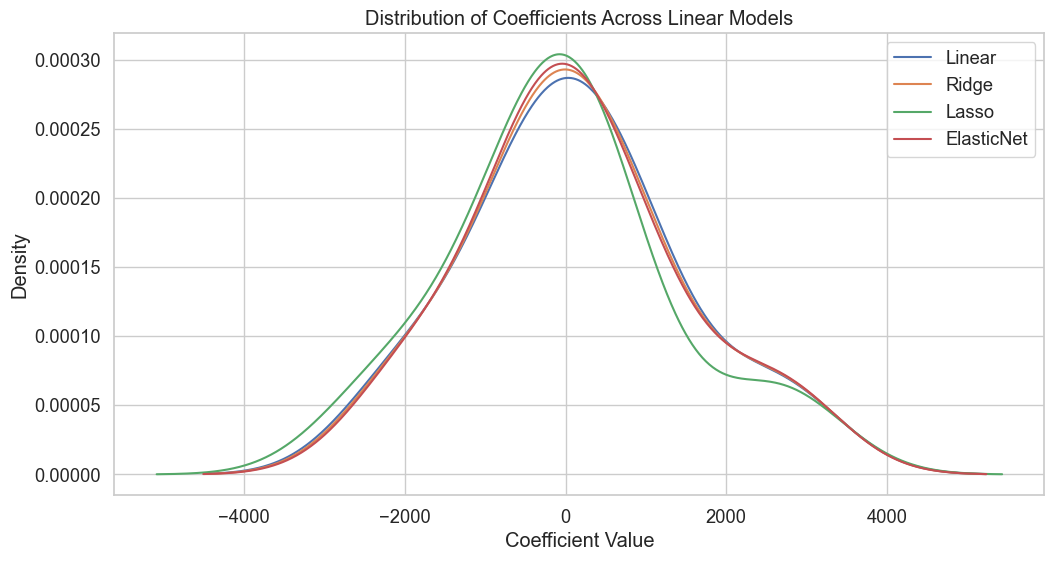

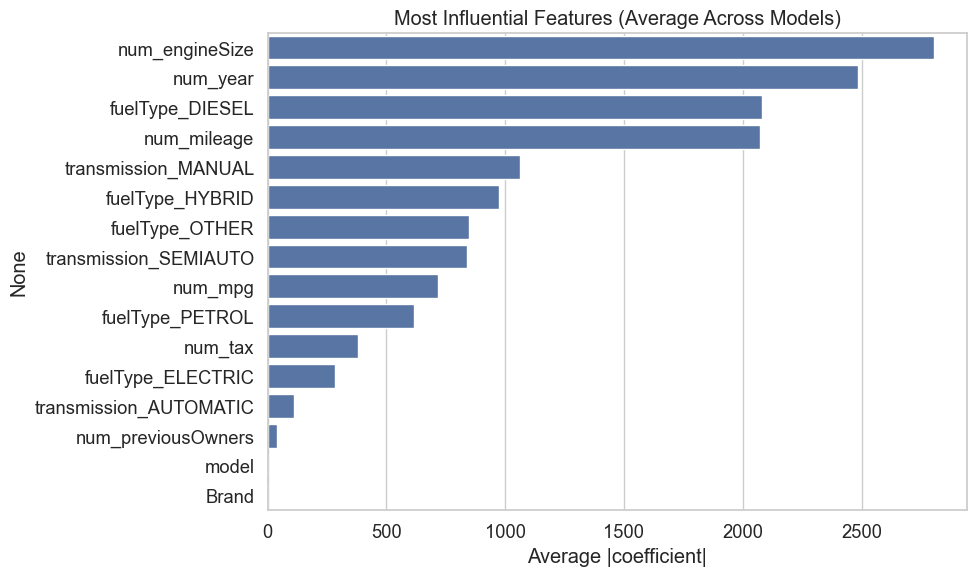

In [ ]:
models = [linreg_final, ridge_final, lasso_final, en_final]
model_names = ["Linear", "Ridge", "Lasso", "ElasticNet"] 

plot_coefficients(models, model_names)

The coefficient distributions show that all linear variants learn almost identical parameter structures, with Ridge and ElasticNet introducing only mild shrinkage and Lasso producing slightly heavier tails due to its selective penalization. This reinforces the earlier conclusion that the underlying linear signal is stable across models and only weakly affected by regularization.

When averaging absolute coefficients, the ranking of influential features is highly consistent: `engineSize`, `year`, `mileage`, and `fuelType` remain dominant, regardless of the specific linear formulation. Categorical encodings like `transmission` also show meaningful but smaller contributions, while `Brand` and `model` provide minimal linear predictive power under the current preprocessing. Together, these results indicate that the linear structure of the problem is well-defined and robust, with slight model differences arising mainly from regularization strength rather than fundamentally different learned relationships.

<br>

In order to deepen our analysis of linear models, we will now conduct a **simple ablation/addition study** where we will take ElasticNet (which we expect to have the best performance among the linear-family) and transform it repeatedly with small changes in the pipeline (removing variables, adding new ones, etc.).

<a id="en-var"></a>
## 8. ElasticNet Variants

### 8.1. Why ElasticNet?

This section will only focus on ElasticNet regressions, since this was the best linear model in the previous trainings and tests (even though the difference between models was minimal). Our goal is for the resulting variants to later join ensemble methods, helping improve other models' performance.

### 8.2. Controlled Feature/Target Experiments

Five ElasticNet variants are assessed using the same 8-fold cross-validation and preprocessing structure to quantify the effect of target scaling, feature removal, alternative age representation, and the inclusion of feature engineering and selection.

For each variant, a small random search over (`alpha`, `l1_ratio`) is executed, reusing the same sampled configurations across folds. All preprocessing is fit exclusively on the training split, and log-target predictions are inverse-transformed before metric computation. Results are exported per variant, and a concise leaderboard summarizes the best configuration according to validation RMSE.

### 8.3. Hyperparameter Search (K-Fold)

In [ ]:
# 0) GLOBAL CONFIG
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Smaller hyperparameter space + fewer configurations, because of computation time
elastic_param_distributions_small = {
    "alpha":    np.logspace(-4, -1, 18),
    "l1_ratio": np.linspace(0.2, 0.9, 8),    
}
N_RANDOM_CONFIGS_SMALL = 15  



# 1) METRICS HELPERS (always reported in €)
def _rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def _bias_pred_minus_true(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_pred) - np.asarray(y_true)))



# 2) ONE FOLD PIPELINE 
def _run_one_fold(
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    y_train: pd.Series,
    y_val: pd.Series,
    params: dict,
    *,
    target_is_log: bool,
    drop_prevowners: bool,
    use_age_instead_of_year: bool,
    use_all_fe: bool,
    fs_keep_ratio: float | None,
    rf_fs_params: dict | None,
):
    """
    Returns fold metrics in € and numeric imputers -> resolvers -> encoding -> scaling -> model,
    with optional: dropping previousOwners, replacing year->age, FE, FS.
    """

    # target transform
    if target_is_log:
        y_train_fit = np.log1p(y_train)
    else:
        y_train_fit = y_train

    # numeric preprocessing 
    year_state = fit_year_median(X_train, year_col="year", model_col="model")
    X_train = transform_year_with_model_median(X_train, state=year_state)
    X_val   = transform_year_with_model_median(X_val,   state=year_state)

    mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
    X_train = transform_mileage_imputer(X_train, state=mileage_state)
    X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

    engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
    X_train = transform_engine_size_imputer(X_train, state=engine_state)
    X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

    tax_state = fit_tax_imputer(X_train, tax_col="tax", do_abs=True)
    X_train = transform_tax_imputer(X_train, state=tax_state)
    X_val   = transform_tax_imputer(X_val,   state=tax_state)

    mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
    X_train = transform_mpg_imputer(X_train, state=mpg_state)
    X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

    # previousOwners imputation ONLY if we still need the column for something:
    # - baseline (1): used as numeric feature
    # - (2)(3)(4): we drop it entirely, so we skip the imputer (cleaner + faster)
    # - (5): we need it to create owners_flagged, so we DO impute then FE drops it
    if (not drop_prevowners) or use_all_fe:
        owners_state = fit_previous_owners_imputer(
            X_train, owners_col="previousOwners", year_col="year", mileage_col="mileage"
        )
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)


    # resolvers 
    brand_state = fit_ambiguous_brand_resolver(
        train_df=X_train, valid_brands=valid_brands,
        brand_col="Brand", model_col="model", year_col="year"
    )
    X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
    X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

    model_state = fit_invalid_model_resolver(
        train_df=X_train, valid_models_by_brand=valid_models_by_brand,
        brand_col="Brand", model_col="model", year_col="year",
        fuel_col="fuelType", mpg_col="mpg"
    )
    X_train, _, _ = transform_invalid_models(X_train, model_state)
    X_val,   _, _ = transform_invalid_models(X_val,   model_state)

    transm_state = fit_transmission_resolver(
        train_df=X_train, valid_transmissions=valid_transmissions,
        transm_col="transmission", brand_col="Brand",
        model_col="model", fuel_col="fuelType"
    )
    X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
    X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

    fuel_state = fit_fueltype_resolver(
        train_df=X_train, valid_fueltypes=valid_fueltypes,
        fuel_col="fuelType", brand_col="Brand",
        model_col="model", transm_col="transmission"
    )
    X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
    X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

    # drop previousOwners entirely (variants 2/3/4)
    if drop_prevowners and (not use_all_fe):
        X_train = X_train.drop(columns=["previousOwners"], errors="ignore")
        X_val   = X_val.drop(columns=["previousOwners"], errors="ignore")

    # age instead of year (variants 3/4/5)
    if use_age_instead_of_year:
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

    # all FE (variant 5)
    engine_bin_as_cat = False
    if use_all_fe:
        # owners_flagged (drops previousOwners)
        X_train = add_owners_flagged(X_train, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
        X_val   = add_owners_flagged(X_val,   owners_col="previousOwners", new_col="owners_flagged", drop_original=True)

        # mileage features (drops mileage; uses age)
        X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
        X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)

        # engine bins (keeps engineSize; adds engine_bin as categorical)
        X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
        X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        engine_bin_as_cat = True


    # encoding (same logic: TE for high-card, OHE for low-card)
    # IMPORTANT: TE is fit on y_train_fit (so for log-target variants it's log1p(y))

    high_card_features = ["Brand", "model"]
    low_card_features  = [c for c in categorical_features if c not in high_card_features]

    low_card_curr = low_card_features + (["engine_bin"] if engine_bin_as_cat else [])

    te = MyTargetEncoder(smoothing=5)
    te.fit(X_train[high_card_features], y_train_fit)
    X_train_high = te.transform(X_train[high_card_features])
    X_val_high   = te.transform(X_val[high_card_features])

    ohe = MyOneHotEncoder()
    ohe.fit(X_train[low_card_curr])
    X_train_low = ohe.transform(X_train[low_card_curr])
    X_val_low   = ohe.transform(X_val[low_card_curr])

    X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
    X_val_cat   = pd.concat([X_val_high,   X_val_low], axis=1)


    # numeric features: "everything else" excluding the raw categorical cols we encoded
    drop_for_numeric = set(high_card_features + low_card_curr)
    numeric_cols_curr = [c for c in X_train.columns if c not in drop_for_numeric]

    # scaling numeric
    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[numeric_cols_curr])
    X_val_num   = scaler.transform(X_val[numeric_cols_curr])

    X_train_num_df = pd.DataFrame(
        X_train_num, index=X_train.index, columns=[f"num_{c}" for c in numeric_cols_curr]
    )
    X_val_num_df = pd.DataFrame(
        X_val_num, index=X_val.index, columns=[f"num_{c}" for c in numeric_cols_curr]
    )

    X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
    X_val_final   = pd.concat([X_val_num_df,   X_val_cat], axis=1)

    # align (safe)
    X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

    # feature selection (variants 4 and 5)
    n_feats_total = int(X_train_final.shape[1])
    n_feats_selected = n_feats_total

    if fs_keep_ratio is not None:
        if rf_fs_params is None:
            raise ValueError("rf_fs_params must be provided when fs_keep_ratio is not None")

        k = int(np.ceil(fs_keep_ratio * n_feats_total))
        k = max(1, min(k, n_feats_total))

        rf_fs = RandomForestRegressor(**rf_fs_params)
        rf_fs.fit(X_train_final, y_train_fit)

        selector = SelectFromModel(
            estimator=rf_fs,
            threshold=-np.inf,
            max_features=k,
            prefit=True
        )

        selected_cols = X_train_final.columns[selector.get_support()]
        n_feats_selected = int(len(selected_cols))

        X_train_final = X_train_final[selected_cols]
        X_val_final   = X_val_final[selected_cols]


    # model (ElasticNet)
    en = ElasticNet(
        alpha=float(params["alpha"]),
        l1_ratio=float(params["l1_ratio"]),
        fit_intercept=True,
        max_iter=10000
    )
    en.fit(X_train_final, y_train_fit)

    pred_tr_fit  = en.predict(X_train_final)
    pred_val_fit = en.predict(X_val_final)

    # invert if trained on log
    if target_is_log:
        pred_tr  = np.expm1(pred_tr_fit)
        pred_val = np.expm1(pred_val_fit)
    else:
        pred_tr  = pred_tr_fit
        pred_val = pred_val_fit

    # metrics in €
    out = {
        "n_features_total": n_feats_total,
        "n_features_selected": n_feats_selected,

        "rmse_tr": _rmse(y_train, pred_tr),
        "rmse_val": _rmse(y_val, pred_val),

        "mae_tr": float(mean_absolute_error(y_train, pred_tr)),
        "mae_val": float(mean_absolute_error(y_val, pred_val)),

        "r2_tr": float(r2_score(y_train, pred_tr)),
        "r2_val": float(r2_score(y_val, pred_val)),

        "bias_tr": _bias_pred_minus_true(y_train, pred_tr),
        "bias_val": _bias_pred_minus_true(y_val, pred_val),
    }
    return out



# 3) RANDOM SEARCH DRIVER 
def run_elastic_variant(
    variant_name: str,
    *,
    target_is_log: bool,
    drop_prevowners: bool,
    use_age_instead_of_year: bool,
    use_all_fe: bool,
    fs_keep_ratio: float | None,
    n_random_configs: int,
):
    sampler = ParameterSampler(
        elastic_param_distributions_small,
        n_iter=n_random_configs,
        random_state=RANDOM_STATE
    )

    log_path = f"elasticnet_{variant_name}_search_log.txt"

    search_results = []
    best_rmse = np.inf
    best_cfg = None

    # RF params for FS (only used if fs_keep_ratio is not None)
    rf_fs_params = None
    if fs_keep_ratio is not None:
        rf_fs_params = {
            "n_estimators": 400,
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 2,
            "max_features": "sqrt",
            "bootstrap": True,
        }

    with open(log_path, "w", encoding="utf-8") as log_file:

        def log_en(msg: str):
            log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
            log_file.flush()

        log_en("# =============================")
        log_en(f"# START OF RANDOM SEARCH ElasticNet | VARIANT={variant_name}")
        log_en("# =============================")
        log_en(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {n_random_configs}")
        log_en(f"param_distributions = {elastic_param_distributions_small}")
        log_en(f"target_is_log = {target_is_log}")
        log_en(f"drop_prevowners = {drop_prevowners}")
        log_en(f"use_age_instead_of_year = {use_age_instead_of_year}")
        log_en(f"use_all_fe = {use_all_fe}")
        log_en(f"fs_keep_ratio = {fs_keep_ratio}")

        for config_id, params in enumerate(sampler, start=1):
            log_en("")
            log_en(f"######## CONFIG {config_id}/{n_random_configs} ########")
            log_en(f"Parameters: {params}")

            fold_rows = []

            for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
                log_en("")
                log_en(f"[C{config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

                X_train = X.iloc[train_idx].copy()
                X_val   = X.iloc[val_idx].copy()
                y_train = y.iloc[train_idx].copy()
                y_val   = y.iloc[val_idx].copy()

                fold_out = _run_one_fold(
                    X_train, X_val, y_train, y_val, params,
                    target_is_log=target_is_log,
                    drop_prevowners=drop_prevowners,
                    use_age_instead_of_year=use_age_instead_of_year,
                    use_all_fe=use_all_fe,
                    fs_keep_ratio=fs_keep_ratio,
                    rf_fs_params=rf_fs_params
                )

                log_en(
                    f"[C{config_id}|F{fold}] TRAIN -> RMSE: {fold_out['rmse_tr']:.2f} | "
                    f"MAE: {fold_out['mae_tr']:.2f} | R2: {fold_out['r2_tr']:.4f} | "
                    f"Bias(pred-true): {fold_out['bias_tr']:.2f} | "
                    f"Feats: {fold_out['n_features_selected']}/{fold_out['n_features_total']}"
                )
                log_en(
                    f"[C{config_id}|F{fold}] VAL   -> RMSE: {fold_out['rmse_val']:.2f} | "
                    f"MAE: {fold_out['mae_val']:.2f} | R2: {fold_out['r2_val']:.4f} | "
                    f"Bias(pred-true): {fold_out['bias_val']:.2f} | "
                    f"Feats: {fold_out['n_features_selected']}/{fold_out['n_features_total']}"
                )

                fold_rows.append(fold_out)

            df_folds = pd.DataFrame(fold_rows)

            mean_rmse_val = float(df_folds["rmse_val"].mean())
            mean_mae_val  = float(df_folds["mae_val"].mean())
            mean_r2_val   = float(df_folds["r2_val"].mean())
            mean_bias_val = float(df_folds["bias_val"].mean())

            mean_rmse_tr = float(df_folds["rmse_tr"].mean())
            mean_mae_tr  = float(df_folds["mae_tr"].mean())
            mean_r2_tr   = float(df_folds["r2_tr"].mean())
            mean_bias_tr = float(df_folds["bias_tr"].mean())

            avg_total = float(df_folds["n_features_total"].mean())
            avg_sel   = float(df_folds["n_features_selected"].mean())

            combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

            log_en(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
            log_en(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
            log_en(f"Config {config_id} - Feats: {avg_sel:.1f}/{avg_total:.1f} | Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

            row = {
                "variant": variant_name,
                "config_id": config_id,
                **params,
                "rmse_train_mean": mean_rmse_tr,
                "mae_train_mean": mean_mae_tr,
                "r2_train_mean": mean_r2_tr,
                "bias_train_mean": mean_bias_tr,
                "rmse_val_mean": mean_rmse_val,
                "mae_val_mean": mean_mae_val,
                "r2_val_mean": mean_r2_val,
                "bias_val_mean": mean_bias_val,
                "avg_features_total": avg_total,
                "avg_features_selected": avg_sel,
                "combo_score": combo_score,
            }
            search_results.append(row)

            if mean_rmse_val < best_rmse:
                best_rmse = mean_rmse_val
                best_cfg = {**params}
                log_en(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {best_rmse:.2f}")

        log_en("")
        log_en("# =============================")
        log_en(f"# END OF RANDOM SEARCH ElasticNet | VARIANT={variant_name}")
        log_en("# =============================")
        log_en(f"Best configuration (min RMSE VAL): {best_cfg}")
        log_en(f"Best average RMSE (VAL): {best_rmse:.2f}")

    results_df = pd.DataFrame(search_results).sort_values("rmse_val_mean", ascending=True).reset_index(drop=True)
    out_csv = f"elasticnet_{variant_name}_random_search_results.csv"
    results_df.to_csv(out_csv, index=False)

    print(f"\n===== {variant_name} =====")
    display(results_df.head(8))
    print("Best config (by VAL RMSE):", best_cfg)
    print("Best VAL RMSE:", best_rmse)
    print("Saved:", out_csv)
    print("Log:", log_path)

    return results_df, best_cfg



# 4) RUN THE 5 VARIANTS

all_results = []

# 1. normal model, all original features, no FE/FS, target=price
res1, best1 = run_elastic_variant(
    "v1_original_price",
    target_is_log=False,
    drop_prevowners=False,
    use_age_instead_of_year=False,
    use_all_fe=False,
    fs_keep_ratio=None,
    n_random_configs=N_RANDOM_CONFIGS_SMALL
)
all_results.append(res1)

# 2. drop prev owners, target=log(price)
res2, best2 = run_elastic_variant(
    "v2_noOwners_logPrice",
    target_is_log=True,
    drop_prevowners=True,
    use_age_instead_of_year=False,
    use_all_fe=False,
    fs_keep_ratio=None,
    n_random_configs=N_RANDOM_CONFIGS_SMALL
)
all_results.append(res2)

# 3. same as 2 + age instead of year, target=log(price)
res3, best3 = run_elastic_variant(
    "v3_noOwners_age_logPrice",
    target_is_log=True,
    drop_prevowners=True,
    use_age_instead_of_year=True,
    use_all_fe=False,
    fs_keep_ratio=None,
    n_random_configs=N_RANDOM_CONFIGS_SMALL
)
all_results.append(res3)

# 4. same as 3 + feature selection 80%
res4, best4 = run_elastic_variant(
    "v4_noOwners_age_logPrice_FS80",
    target_is_log=True,
    drop_prevowners=True,
    use_age_instead_of_year=True,
    use_all_fe=False,
    fs_keep_ratio=0.80,
    n_random_configs=N_RANDOM_CONFIGS_SMALL
)
all_results.append(res4)

# 5. same as 3 but FS65 + all FE features
res5, best5 = run_elastic_variant(
    "v5_age_logPrice_allFE_FS65",
    target_is_log=True,
    drop_prevowners=True,           # raw previousOwners is not used (FE turns it into owners_flagged + drops raw)
    use_age_instead_of_year=True,
    use_all_fe=True,                # owners_flagged, mileage features, engine_bin
    fs_keep_ratio=0.65,
    n_random_configs=N_RANDOM_CONFIGS_SMALL
)
all_results.append(res5)


# 5) COMBINED LEADERBOARD (best row per variant by VAL RMSE)
combined = pd.concat(all_results, axis=0, ignore_index=True)
leader = (
    combined.sort_values(["variant", "rmse_val_mean"])
            .groupby("variant", as_index=False)
            .head(1)
            .sort_values("rmse_val_mean")
            .reset_index(drop=True)
)

print("\n===== BEST CONFIG PER VARIANT (by VAL RMSE) =====")
cols_lead = ["variant", "rmse_val_mean", "mae_val_mean", "r2_val_mean", "bias_val_mean",
             "avg_features_selected", "avg_features_total", "alpha", "l1_ratio"]
display(leader[cols_lead])

leader.to_csv("elasticnet_variants_best_per_variant.csv", index=False)
print("Saved: elasticnet_variants_best_per_variant.csv")

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.472e+11, tolerance: 6.343e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.442e+11, tolerance: 6.312e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg


===== v1_original_price =====


,variant,config_id,l1_ratio,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_val_mean,mae_val_mean,r2_val_mean,bias_val_mean,avg_features_total,avg_features_selected,combo_score
0,v1_original_price,10,0.4,0.000225,4157.775076,2647.107414,0.817657,-8.711351e-14,4183.249508,2653.410701,0.815357,-0.055747,16.0,16.0,3418.330105
1,v1_original_price,2,0.5,0.000225,4157.774270,2647.126496,0.817657,3.290408e-13,4183.250967,2653.431793,0.815357,-0.055942,16.0,16.0,3418.341380
2,v1_original_price,6,0.6,0.000150,4157.772306,2647.172287,0.817657,2.703870e-13,4183.257791,2653.485361,0.815357,-0.056323,16.0,16.0,3418.371576
3,v1_original_price,11,0.5,0.001145,4157.796481,2646.758278,0.817655,-2.841174e-13,4183.260194,2653.051929,0.815356,-0.053019,16.0,16.0,3418.156061
4,v1_original_price,12,0.8,0.003875,4157.810841,2646.605958,0.817653,-4.403346e-13,4183.274541,2652.897177,0.815355,-0.052148,16.0,16.0,3418.085859
5,v1_original_price,5,0.2,0.001719,4157.863228,2646.181899,0.817649,-8.100501e-13,4183.331531,2652.472463,0.815350,-0.050349,16.0,16.0,3417.901997
6,v1_original_price,9,0.4,0.002581,4157.880662,2646.064024,0.817647,-1.318282e-12,4183.351027,2652.355716,0.815348,-0.049935,16.0,16.0,3417.853372
7,v1_original_price,13,0.8,0.008733,4157.902163,2645.929819,0.817645,1.499324e-14,4183.375197,2652.222530,0.815346,-0.049478,16.0,16.0,3417.798864


Best config (by VAL RMSE): {'l1_ratio': np.float64(0.4), 'alpha': np.float64(0.00022539339047347913)}
Best VAL RMSE: 4183.249508112975
Saved: elasticnet_v1_original_price_random_search_results.csv
Log: elasticnet_v1_original_price_search_log.txt

===== v2_noOwners_logPrice =====


,variant,config_id,l1_ratio,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_val_mean,mae_val_mean,r2_val_mean,bias_val_mean,avg_features_total,avg_features_selected,combo_score
0,v2_noOwners_logPrice,5,0.2,0.001719,3537.139420,2106.553532,0.868029,-232.924160,3559.759163,2111.416013,0.866309,-236.305740,15.0,15.0,2835.587588
1,v2_noOwners_logPrice,10,0.4,0.000225,3539.268844,2108.591907,0.867870,-217.692454,3562.172897,2113.527201,0.866128,-221.165105,15.0,15.0,2837.850049
2,v2_noOwners_logPrice,2,0.5,0.000225,3539.578229,2108.642309,0.867847,-218.062264,3562.498838,2113.570669,0.866104,-221.534997,15.0,15.0,2838.034754
3,v2_noOwners_logPrice,6,0.6,0.000150,3539.600064,2108.751353,0.867845,-217.105466,3562.528265,2113.696438,0.866102,-220.582587,15.0,15.0,2838.112352
4,v2_noOwners_logPrice,8,0.3,0.002581,3540.893519,2106.933379,0.867749,-245.866109,3563.498201,2111.831155,0.866027,-249.219646,15.0,15.0,2837.664678
5,v2_noOwners_logPrice,11,0.5,0.001145,3542.369487,2108.095653,0.867638,-232.237276,3565.218832,2112.982788,0.865899,-235.662501,15.0,15.0,2839.100810
6,v2_noOwners_logPrice,9,0.4,0.002581,3545.049937,2108.231589,0.867438,-249.792941,3567.780630,2113.133241,0.865705,-253.157715,15.0,15.0,2840.456935
7,v2_noOwners_logPrice,3,0.4,0.005817,3564.981661,2118.726879,0.865944,-290.594526,3587.194791,2123.670383,0.864238,-293.860249,15.0,15.0,2855.432587


...

Best config (by VAL RMSE): {'l1_ratio': np.float64(0.2), 'alpha': np.float64(0.0017190722018585747)}
Best VAL RMSE: 3561.4570537197
Saved: elasticnet_v4_noOwners_age_logPrice_FS80_random_search_results.csv
Log: elasticnet_v4_noOwners_age_logPrice_FS80_search_log.txt

===== v5_age_logPrice_allFE_FS65 =====


,variant,config_id,l1_ratio,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_val_mean,mae_val_mean,r2_val_mean,bias_val_mean,avg_features_total,avg_features_selected,combo_score
0,v5_age_logPrice_allFE_FS65,5,0.2,0.001719,3714.439377,2199.687826,0.854467,-259.808290,3736.791217,2204.344839,0.852690,-262.970696,25.0,17.0,2970.568028
1,v5_age_logPrice_allFE_FS65,10,0.4,0.000225,3718.308972,2199.725143,0.854164,-244.108125,3740.967119,2204.536781,0.852360,-247.308588,25.0,17.0,2972.751950
2,v5_age_logPrice_allFE_FS65,2,0.5,0.000225,3718.316217,2199.770488,0.854163,-244.519387,3740.973458,2204.584252,0.852359,-247.722380,25.0,17.0,2972.778855
3,v5_age_logPrice_allFE_FS65,8,0.3,0.002581,3719.536372,2205.598179,0.854068,-272.731326,3741.293392,2210.137718,0.852335,-275.922549,25.0,17.0,2975.715555
4,v5_age_logPrice_allFE_FS65,6,0.6,0.000150,3718.666817,2199.862514,0.854136,-243.517895,3741.340652,2204.684058,0.852330,-246.721535,25.0,17.0,2973.012355
5,v5_age_logPrice_allFE_FS65,11,0.5,0.001145,3719.835390,2203.149566,0.854044,-259.232422,3742.160417,2207.819761,0.852266,-262.465444,25.0,17.0,2974.990089
6,v5_age_logPrice_allFE_FS65,9,0.4,0.002581,3725.448761,2210.060053,0.853604,-276.608375,3747.367452,2214.635823,0.851854,-279.818476,25.0,17.0,2981.001638
7,v5_age_logPrice_allFE_FS65,3,0.4,0.005817,3737.036099,2219.685651,0.852692,-320.813817,3758.824253,2224.216920,0.850944,-323.883406,25.0,17.0,2991.520587


Best config (by VAL RMSE): {'l1_ratio': np.float64(0.2), 'alpha': np.float64(0.0017190722018585747)}
Best VAL RMSE: 3736.791217126435
Saved: elasticnet_v5_age_logPrice_allFE_FS65_random_search_results.csv
Log: elasticnet_v5_age_logPrice_allFE_FS65_search_log.txt

===== BEST CONFIG PER VARIANT (by VAL RMSE) =====


,variant,rmse_val_mean,mae_val_mean,r2_val_mean,bias_val_mean,avg_features_selected,avg_features_total,alpha,l1_ratio
0,v3_noOwners_age_logPrice,3559.711437,2111.398107,0.866313,-236.317400,15.0,15.0,0.001719,0.2
1,v2_noOwners_logPrice,3559.759163,2111.416013,0.866309,-236.305740,15.0,15.0,0.001719,0.2
2,v4_noOwners_age_logPrice_FS80,3561.457054,2111.884465,0.866181,-236.575645,12.0,15.0,0.001719,0.2
3,v5_age_logPrice_allFE_FS65,3736.791217,2204.344839,0.852690,-262.970696,17.0,25.0,0.001719,0.2
4,v1_original_price,4183.249508,2653.410701,0.815357,-0.055747,16.0,16.0,0.000225,0.4


Saved: elasticnet_variants_best_per_variant.csv


<a id="summary"></a>
## 10. Closing summary

This notebook examined four linear and regularized models within a unified preprocessing and cross-validation framework.

Ordinary Least Squares established the interpretability baseline, revealing the linear structure of the data and defining the minimum performance threshold. Ridge addressed coefficient instability by shrinking correlated predictors, Lasso explored sparsity and automatic feature selection, and ElasticNet provided a balanced middle ground capable of both stabilization and variable reduction.

The insights gained here set the stage for evaluating more expressive nonlinear models in subsequent notebooks and help justify whether added complexity yields meaningful improvements in predictive performance.

### 10.1. Visualizing the model performance and feature importance

In order to compare all models in a more "fair" way, we used the best hyperparameter configuration obtained in the random search, under a consistent setting: removing `previousOwners` and log-transforming the target, no feature engineering and no feature selection. This choice is also motivated by the fact that this baseline was the best-performing scenario for the stacking model (our final model from this project).

We included the following visualizations: __Predicted vs. True Values plot__, __Residuals vs. Predicted Values plot__, __Residual Distribution plot__, __Permutation Importance plot__, __SHAP Summary Bar plot and SHAP Beeswarm plot__.

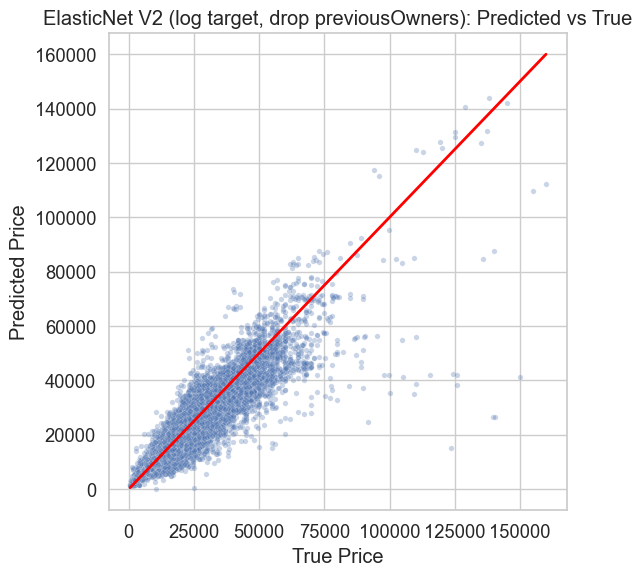

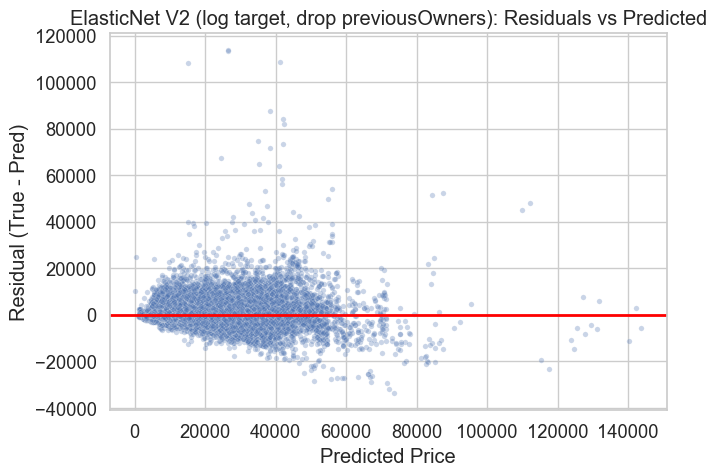

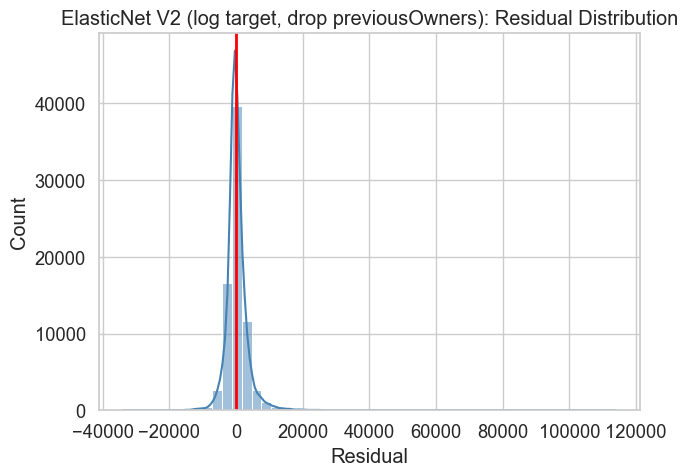

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_445/4128551160.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


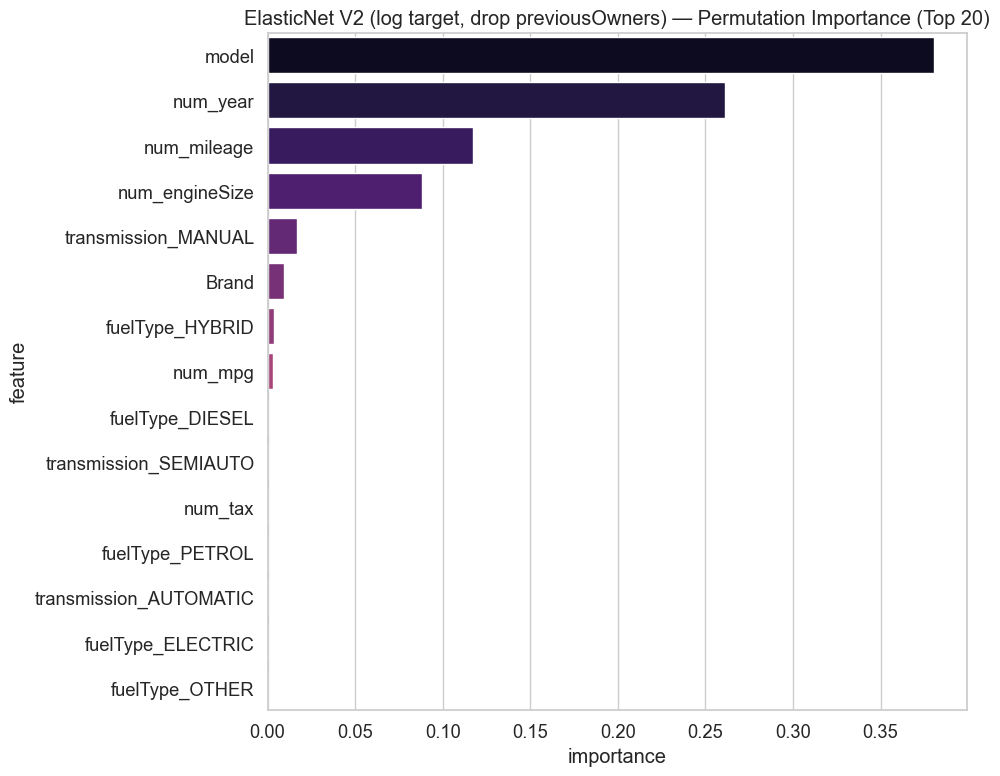


SHAP for ElasticNet V2 (log target, drop previousOwners) (sample size = 2000)


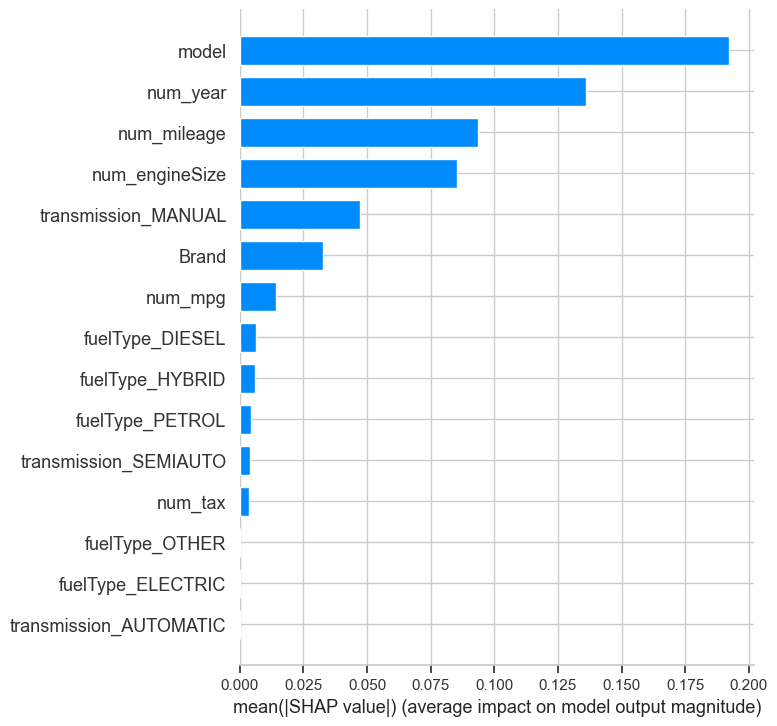

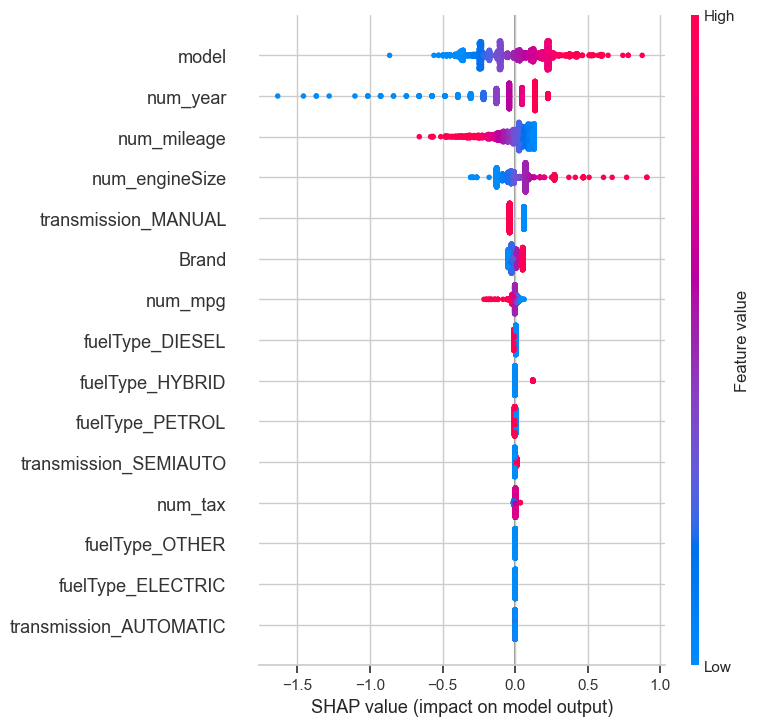

In [4]:
# VARIANT 2: manual best params (so that we can run this cell and not the previous one) + diagnostics
#   - drop previousOwners
#   - target = log1p(price)
#   - NO feature engineering
#   - NO feature selection

valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold configuration
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# 0) MANUAL BEST PARAMS
BEST_ALPHA_V2    = 0.001719   # best alpha for variant 2
BEST_L1RATIO_V2  = 0.2   # best l1_ratio for variant 2

# 1) Variant 2 switches
TARGET_IS_LOG = True
DROP_PREVOWNERS = True
USE_AGE_INSTEAD_OF_YEAR = False
USE_ALL_FE = False
FS_KEEP_RATIO = None

# 2) Start from full data
X_full_raw = X.copy()
y_full = y.copy().astype(float)
y_full_log = np.log1p(y_full)

X_full_proc = X_full_raw.copy()

# 3) Numeric preprocessing (fit on full, transform full)
year_state = fit_year_median(X_full_proc, year_col="year", model_col="model")
X_full_proc = transform_year_with_model_median(X_full_proc, state=year_state)

mileage_state = fit_mileage_imputer(X_full_proc, mileage_col="mileage", do_abs=True)
X_full_proc = transform_mileage_imputer(X_full_proc, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full_proc, engine_col="engineSize")
X_full_proc = transform_engine_size_imputer(X_full_proc, state=engine_state)

tax_state = fit_tax_imputer(X_full_proc, tax_col="tax", do_abs=True)
X_full_proc = transform_tax_imputer(X_full_proc, state=tax_state)

mpg_state = fit_mpg_imputer(X_full_proc, mpg_col="mpg", do_abs=True)
X_full_proc = transform_mpg_imputer(X_full_proc, state=mpg_state)

# Variant 2: previousOwners is DROPPED and not used for FE -> skip its imputer

# 4) Resolvers (fit on full, transform full)
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full_proc, valid_brands=valid_brands,
    brand_col="Brand", model_col="model", year_col="year"
)
X_full_proc, _, _ = transform_ambiguous_brands(X_full_proc, brand_state)

model_state = fit_invalid_model_resolver(
    train_df=X_full_proc, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year",
    fuel_col="fuelType", mpg_col="mpg"
)
X_full_proc, _, _ = transform_invalid_models(X_full_proc, model_state)

transm_state = fit_transmission_resolver(
    train_df=X_full_proc, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand",
    model_col="model", fuel_col="fuelType"
)
X_full_proc, _, _ = transform_transmission_resolver(X_full_proc, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full_proc, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand",
    model_col="model", transm_col="transmission"
)
X_full_proc, _, _ = transform_fueltype_resolver(X_full_proc, fuel_state)

# 5) Drop previousOwners 
X_full_proc = X_full_proc.drop(columns=["previousOwners"], errors="ignore")

# 6) Encoding (TE on Brand/model, OHE on low-card)
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]
low_card_curr = low_card_features  # no engine_bin for variant 2

te = MyTargetEncoder(smoothing=5)
te.fit(X_full_proc[high_card_features], y_full_log)  # IMPORTANT: log target
X_full_high = te.transform(X_full_proc[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full_proc[low_card_curr])
X_full_low = ohe.transform(X_full_proc[low_card_curr])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)

# 7) Numeric columns + scaling
drop_for_numeric = set(high_card_features + low_card_curr)
numeric_cols_curr = [c for c in X_full_proc.columns if c not in drop_for_numeric]

scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full_proc[numeric_cols_curr])

X_full_num_df = pd.DataFrame(
    X_full_num, index=X_full_proc.index, columns=[f"num_{c}" for c in numeric_cols_curr]
)

# Final matrix used to fit ElasticNet
X_full_sel = pd.concat([X_full_num_df, X_full_cat], axis=1)


# 8) Fit ElasticNet with manual params
en_v2 = ElasticNet(
    alpha=float(BEST_ALPHA_V2),
    l1_ratio=float(BEST_L1RATIO_V2),
    fit_intercept=True,
    max_iter=10000,
    random_state=RANDOM_STATE
)
en_v2.fit(X_full_sel, y_full_log)


# 9) Visualizations / interpretation helpers
plot_pred_vs_true_fs(en_v2, "ElasticNet V2 (log target, drop previousOwners)")
plot_residuals_fs(en_v2, "ElasticNet V2 (log target, drop previousOwners)")
plot_residual_distribution_fs(en_v2, "ElasticNet V2 (log target, drop previousOwners)")
plot_permutation_importance_fs(en_v2, "ElasticNet V2 (log target, drop previousOwners)", n_repeats=5, top=20)

X_shap = X_full_sel.copy()
X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype 
apply_shap_fs(en_v2, X_shap, model_name="ElasticNet V2 (log target, drop previousOwners)", sample_size=2000)

- Deviations from the diagonal line in the *Predicted vs True* plot show systematic bias, specially under-predictions. Low-priced cars tend to be well-ish predicted, while **higher-priced cars are increasingly under-predicted**. The spread grows with price, indicating **heteroskedasticity and limited linear fit** at the most expensive cars. 
- Residuals are not randomly scattered, and form a roughly centered distribution but with heavy tails: variance increases with predicted price, confirming heteroskedasticity and large ocasional errors. This structured pattern indicates that **linearity assumptions are violated** and that the model struggles with nonlinear price dynamics.
- **`Model` identity dominates prediction power**, followed by `engine size`, `year`, and `mileage`. `Fuel type` and `transmission` contribute modestly. `Brand` has low importance because its information is already captured through `model`. Overall, the model relies heavily on a small group of numeric and categorical predictors. 
- Each top feature shows clear directional effects: **newer cars, larger engines, and lower mileage push predictions upward**, while older cars and high mileage lower them. Feature impacts are asymmetric, especially for `model` and `engine size`. Most low-ranked features show tightly centered SHAP values, confirming minimal effect.

> Note: an important takeaway from the *Predicted vs True* plot is that **negative values are being predicted**, which does not make sense (but it is typical expected behavior from a linear regression model). 

### 10.2. Results obtained and overall performance discussion

| Variant / Experiment                           | FS ratio | RMSE (val) | MAE (val) | R² (val) | #Features      | Best configuration |
|------------------------------------------------|:--------:|-----------:|----------:|---------:|---------------:|-------------|
| 1) Original features (price target)            | —        | 4183.25    | 2653.41   | 0.815    | 16             | α=0.0002, l1=0.40 |
| 2) No previousOwners + log target              | —        | 3559.75    | 2111.41   | 0.866    | 15             | α=0.0017, l1=0.20 |
| 3) 2 + age instead of year                     | —        | 3559.71    | 2111.40   | 0.866    | 15             | α=0.0017, l1=0.20 |
| 4) 3 + FS80%                                   | 0.80     | 3561.46    | 2111.88   | 0.866    | 12             | α=0.0017, l1=0.20 |
| 5) Full FE + FS (65%), log target              | 0.65     | 3736.79    | 2204.34   | 0.853    | 17             | α=0.0017, l1=0.20 |


*Table 1 - Best configuration and main metrics for each experiment*

Table 1 summarizes the best-performing configuration for each ElasticNet variant under a unified 8-fold cross-validation framework.  
**Log-transforming the target and removing `previousOwners` yielded the largest reduction in error**, while feature selection actually worsen the performance, since regularization was in place. 

Removing `previousOwners`, changing `year`to `age` and log-transforming `price` provided the best Elastic Net regression.